# Multi-modal RAG with LangChain

This notebook builds a multimodal RAG pipeline over a PDF (text + tables + images) using **LangChain** and **Google Gemini** models. It was adapted to run cleanly on Google Colab with a single API key (no OpenAI / Groq keys required).

## Setup

Install the system packages and Python dependencies needed to run the notebook.

In [1]:
# System dependencies needed by `unstructured` to parse PDFs (tables, images, OCR).
# This notebook is meant to run on Google Colab (Linux), so we install via apt-get.
!apt-get -qq update
!apt-get -qq install -y poppler-utils tesseract-ocr libmagic-dev > /dev/null


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [2]:
%pip install -Uq "unstructured[all-docs]" lxml
%pip install -Uq chromadb tiktoken
%pip install -Uq langchain langchain-community langchain-chroma langchain-google-genai
%pip install -Uq python-dotenv

# Colab currently ships a broken Pillow 12.0.0 build (ImageText.py references a symbol
# missing from that build's _typing.py), which breaks unstructured's PDF parsing with:
#   ImportError: cannot import name '_Ink' from 'PIL._typing'
# Pin Pillow below 12 as the LAST install so it "wins" over whatever version
# unstructured/other packages pulled in above.
%pip install -Uq "pillow<12,>=10"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 19.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 45.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.9/109.9 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.2/542.2 kB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 453.8/453.8 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━

### Set your Gemini API key

This notebook now uses **Google Gemini** for *everything* (text/table summarization, image summarization, the multimodal question-answering step, and embeddings), so you only need **one** API key.

1. Get a free key from [Google AI Studio](https://aistudio.google.com/apikey).
2. Run the cell below and paste the key when prompted (it will not be shown/echoed).

> Tip: on Colab you can instead store the key once in the 🔑 **Secrets** tab (left sidebar) under the name `GOOGLE_API_KEY` and enable notebook access — the cell below will pick it up automatically and skip the manual prompt.

In [3]:
import os

try:
    # If running on Colab and you saved the key as a Colab secret named GOOGLE_API_KEY,
    # this will grab it automatically.
    from google.colab import userdata
    os.environ["GOOGLE_API_KEY"] = userdata.get("GOOGLE_API_KEY")
except Exception:
    pass

if not os.environ.get("GOOGLE_API_KEY"):
    from getpass import getpass
    os.environ["GOOGLE_API_KEY"] = getpass("Enter your Google Gemini API key: ")

print("Gemini API key is set:", bool(os.environ.get("GOOGLE_API_KEY")))


Gemini API key is set: True


## Get a sample PDF

The original notebook expected a local file at `./content/attention.pdf` that doesn't exist by default on a fresh Colab runtime — this was one of the causes of the errors. We download the "Attention Is All You Need" paper from arXiv to use as our example document. Feel free to replace this with your own PDF (just upload it and update `file_path`).

In [4]:
import os

output_path = "./content/"
os.makedirs(output_path, exist_ok=True)

file_path = output_path + "attention.pdf"

if not os.path.exists(file_path):
    !wget -q "https://arxiv.org/pdf/1706.03762.pdf" -O "{file_path}"

print("PDF ready at:", file_path, "-", os.path.getsize(file_path), "bytes")


PDF ready at: ./content/attention.pdf - 2215244 bytes


## Extract the data

Extract the elements of the PDF that we will be able to use in the retrieval process. These elements can be: Text, Images, Tables, etc.

### Partition PDF tables, text, and images

In [5]:
from unstructured.partition.pdf import partition_pdf

# Reference: https://docs.unstructured.io/open-source/core-functionality/chunking
chunks = partition_pdf(
    filename=file_path,
    infer_table_structure=True,            # extract tables
    strategy="hi_res",                     # mandatory to infer tables

    extract_image_block_types=["Image"],   # Add 'Table' to list to extract image of tables
    # image_output_dir_path=output_path,   # if None, images and tables will saved in base64

    extract_image_block_to_payload=True,   # if true, will extract base64 for API usage

    chunking_strategy="by_title",          # or 'basic'
    max_characters=10000,                  # defaults to 500
    combine_text_under_n_chars=2000,       # defaults to 0
    new_after_n_chars=6000,
)


yolox_l0.05.onnx: reconstructing file:   0%|          |  0.00B /  217MB            

yolox_l0.05.onnx: downloading bytes:           |  0.00B            

preprocessor_config.json:   0%|          | 0.00/274 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.47k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  115MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/367 [00:00<?, ?it/s]

In [6]:
# We get 2 types of elements from the partition_pdf function
set([str(type(el)) for el in chunks])


{"<class 'unstructured.documents.elements.CompositeElement'>",
 "<class 'unstructured.documents.elements.Table'>"}

In [7]:
# Each CompositeElement contains a bunch of related elements.
# This makes it easy to use these elements together in a RAG pipeline.

chunks[3].metadata.orig_elements


In [8]:
# This is what an extracted image looks like.
# It contains the base64 representation only because we set the param extract_image_block_to_payload=True

elements = chunks[3].metadata.orig_elements
chunk_images = [el for el in elements if 'Image' in str(type(el))]
chunk_images[0].to_dict() if chunk_images else "No images found in this chunk"


{'type': 'Image',
 'element_id': '5b40cc27-3732-418a-9071-60cfe42000e9',
 'text': '',
 'metadata': {'coordinates': {'points': ((np.float64(850.5),
     np.float64(457.0659722222226)),
    (np.float64(850.5), np.float64(1075.8659722222224)),
    (np.float64(1162.0), np.float64(1075.8659722222224)),
    (np.float64(1162.0), np.float64(457.0659722222226))),
   'system': 'PixelSpace',
   'layout_width': 2975,
   'layout_height': 3850},
  'last_modified': '2024-04-12T23:47:34',
  'filetype': 'PNG',
  'languages': ['eng'],
  'page_number': 4,
  'image_base64': '...',
  'image_mime_type': 'image/jpeg'}}

### Separate extracted elements into tables, text, and images

In [9]:
# separate tables from texts
tables = []
texts = []

for chunk in chunks:
    if "Table" in str(type(chunk)):
        tables.append(chunk)

    if "CompositeElement" in str(type(chunk)):
        texts.append(chunk)

print(f"{len(texts)} text chunks, {len(tables)} tables")


14 text chunks, 4 tables


In [10]:
# Get the images from the CompositeElement objects
def get_images_base64(chunks):
    images_b64 = []
    for chunk in chunks:
        if "CompositeElement" in str(type(chunk)):
            chunk_els = chunk.metadata.orig_elements
            for el in chunk_els:
                if "Image" in str(type(el)):
                    images_b64.append(el.metadata.image_base64)
    return images_b64

images = get_images_base64(chunks)
print(f"{len(images)} images extracted")


7 images extracted


#### Check what the images look like

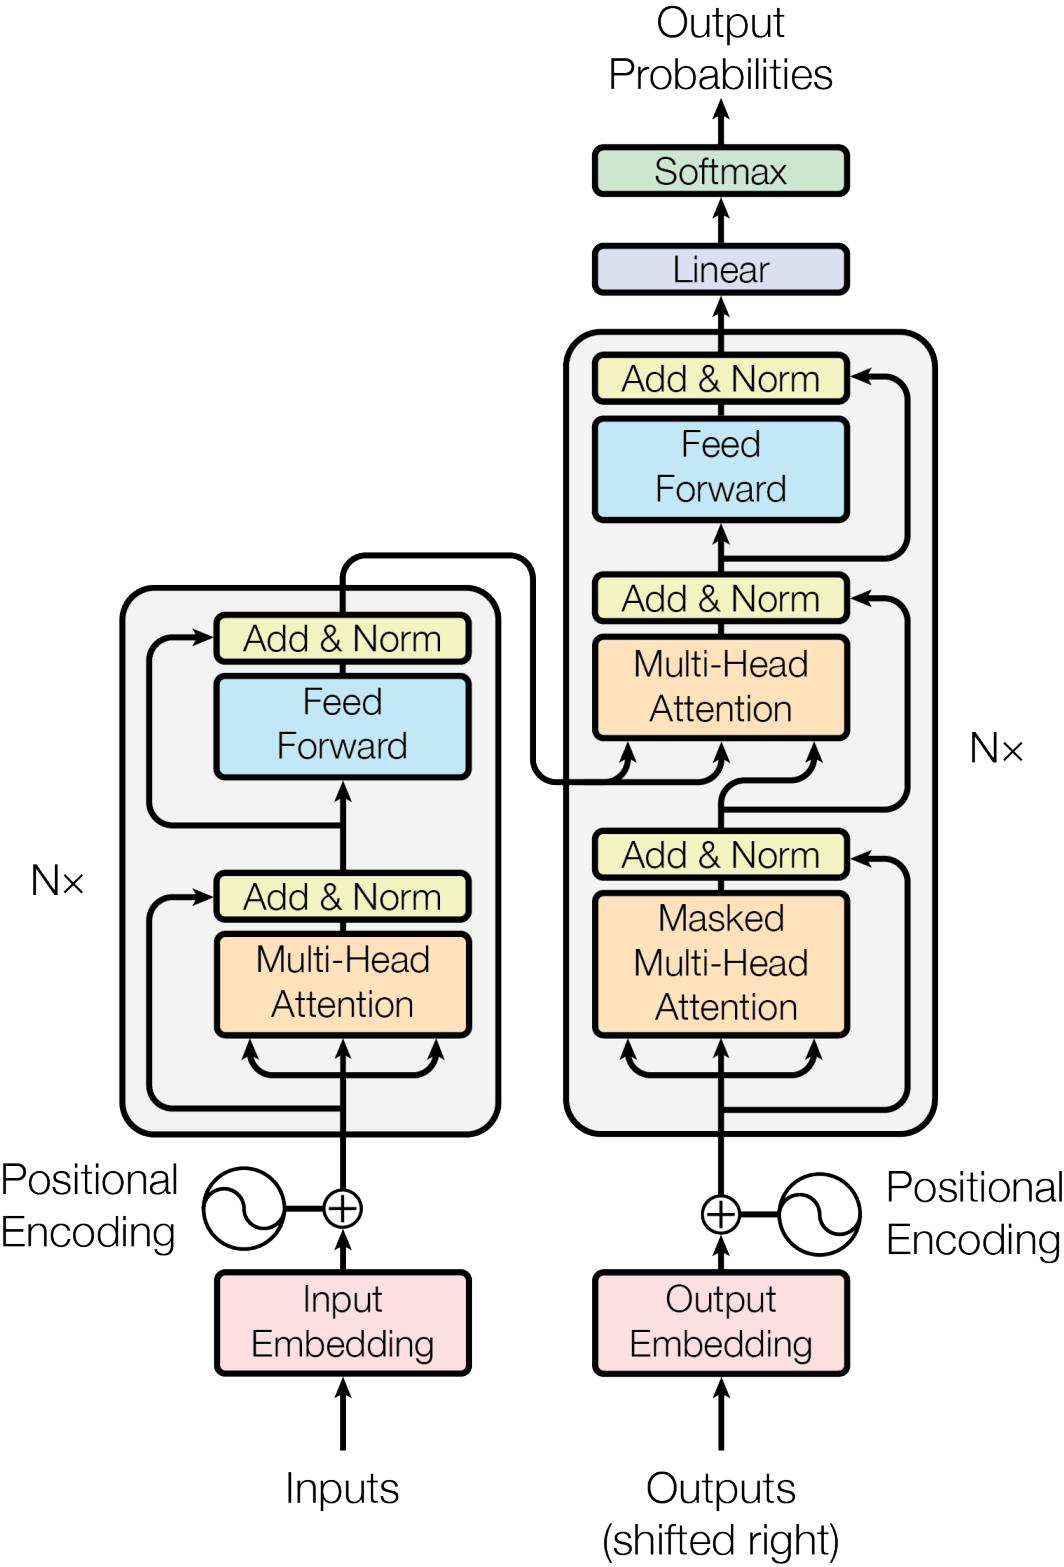

In [11]:
import base64
from IPython.display import Image, display

def display_base64_image(base64_code):
    # Decode the base64 string to binary
    image_data = base64.b64decode(base64_code)
    # Display the image
    display(Image(data=image_data))

if images:
    display_base64_image(images[0])
else:
    print("No images were extracted from this PDF.")


## Summarize the data

Create a summary of each element extracted from the PDF. This summary will be vectorized and used in the retrieval process.

**Note:** the original notebook used OpenAI (and Groq) here. We now use a single **Gemini** chat model (`gemini-2.5-flash`) for text, table, *and* image summarization, so a single `GOOGLE_API_KEY` is all you need.

### Text and Table summaries

In [12]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
import time

# Prompt
prompt_text = """
You are an assistant tasked with summarizing tables and text.
Give a concise summary of the table or text.

Respond only with the summary, no additional comment.
Do not start your message by saying "Here is a summary" or anything like that.
Just give the summary as it is.

Table or text chunk: {element}

"""
prompt = ChatPromptTemplate.from_template(prompt_text)

# We use the `gemini-flash-lite-latest` ALIAS rather than a pinned dated model name, so this
# notebook keeps working even after specific dated model names get deprecated for new API keys.
llm = ChatGoogleGenerativeAI(model="gemini-flash-lite-latest")

summarize_chain = {"element": lambda x: x} | prompt | llm | StrOutputParser()


def run_with_backoff(chain, items, pause_seconds=5, max_retries=8, label="item"):
    """Call chain.invoke on each item ONE AT A TIME, pausing between calls to stay under the
    free tier's per-minute quota, and backing off progressively if we still hit a 429
    (RESOURCE_EXHAUSTED). This is more reliable than batching + a rate limiter, since the
    built-in retry logic doesn't always respect Google's suggested wait time exactly.
    """
    results = []
    for i, item in enumerate(items):
        for attempt in range(max_retries):
            try:
                results.append(chain.invoke(item))
                break
            except Exception as e:
                if "RESOURCE_EXHAUSTED" in str(e) or "429" in str(e):
                    wait = pause_seconds * (attempt + 2)  # progressively longer backoff
                    print(f"  Rate limited on {label} {i + 1}/{len(items)} "
                          f"- waiting {wait}s (retry {attempt + 1}/{max_retries})...")
                    time.sleep(wait)
                else:
                    raise
        else:
            raise RuntimeError(
                f"Failed to process {label} {i + 1} after {max_retries} retries due to rate limiting. "
                "Try again in a minute, or check https://aistudio.google.com/usage for your current limits."
            )
        time.sleep(pause_seconds)  # pace ourselves even after a successful call
    return results


In [13]:
# Quick heads-up: the free tier is roughly 15 requests/minute for Flash-Lite models, so with a
# 5s pause between calls this cell will take a few minutes for a paper-sized PDF. That's expected.
print(f"About to summarize {len(texts)} text chunks + {len(tables)} tables "
      f"({len(texts) + len(tables)} API calls, paced ~5s apart).")

# Summarize text
texts_str = [text.text for text in texts]
text_summaries = run_with_backoff(summarize_chain, texts_str, pause_seconds=5, label="text chunk")

# Summarize tables
tables_html = [table.metadata.text_as_html for table in tables]
table_summaries = run_with_backoff(summarize_chain, tables_html, pause_seconds=5, label="table")


About to summarize 14 text chunks + 4 tables (18 API calls, paced ~5s apart).


In [14]:
text_summaries

['The paper introduces the Transformer, a novel sequence transduction model architecture based solely on attention mechanisms, eliminating the need for recurrence and convolutions. Evaluated on machine translation and constituency parsing tasks, the Transformer achieves superior translation quality, greater parallelizability, and significantly reduced training times compared to existing recurrent or convolutional models.',
 'While recurrent neural networks and convolutions are standard for sequence modeling, their sequential nature limits parallelization and efficient handling of long-range dependencies. To overcome this, the Transformer is introduced as a novel architecture that relies entirely on self-attention mechanisms to compute representations of input and output sequences without using recurrence or convolutions, enabling significantly greater parallelization and achieving state-of-the-art translation quality.',
 'The Transformer model adopts an encoder-decoder architecture uti

### Image summaries

We use the same Gemini model (which is natively multimodal) to produce the image summaries — no separate vision-specific model or API key needed.

In [15]:
prompt_template = """Describe the image in detail. For context,
                  the image is part of a research paper explaining the transformers
                  architecture. Be specific about graphs, such as bar plots."""

messages = [
    (
        "user",
        [
            {"type": "text", "text": prompt_template},
            {
                "type": "image_url",
                # Gemini expects the image_url value to be the data URI/URL string directly
                # (not nested under an extra "url" key like the OpenAI format).
                "image_url": "data:image/jpeg;base64,{image}",
            },
        ],
    )
]

image_prompt = ChatPromptTemplate.from_messages(messages)

# Reuse the same `llm` defined earlier so image calls share the same paced, retrying helper.
image_chain = image_prompt | llm | StrOutputParser()

image_summaries = run_with_backoff(image_chain, images, pause_seconds=5, label="image") if images else []


In [16]:
image_summaries

['Based on the image from the research paper, here is a detailed description of the Transformer architecture diagram:\n\nThe image is a block diagram illustrating the classic Transformer model architecture, which consists of two main sections: an **Encoder** on the left and a **Decoder** on the right. \n\n### **Encoder (Left Side)**\n* **Inputs:** At the very bottom, "Inputs" enter the pipeline and pass into an **Input Embedding** block (colored pink).\n* **Positional Encoding:** The input embeddings are combined with "Positional Encoding" (represented by a circle containing a sine wave symbol) using an addition operation ($\\bigoplus$).\n* **Encoder Stack ($N\\times$):** The combined output flows upward into a grey-boxed encoder block that is repeated $N$ times. Inside this block, from bottom to top, data passes through:\n  1. A **Multi-Head Attention** layer (orange).\n  2. An **Add & Norm** layer (yellow-green), with a residual connection bypassing the attention layer.\n  3. A **Fee

In [17]:
if image_summaries:
    print(image_summaries[0])


Based on the image from the research paper, here is a detailed description of the Transformer architecture diagram:

The image is a block diagram illustrating the classic Transformer model architecture, which consists of two main sections: an **Encoder** on the left and a **Decoder** on the right. 

### **Encoder (Left Side)**
* **Inputs:** At the very bottom, "Inputs" enter the pipeline and pass into an **Input Embedding** block (colored pink).
* **Positional Encoding:** The input embeddings are combined with "Positional Encoding" (represented by a circle containing a sine wave symbol) using an addition operation ($\bigoplus$).
* **Encoder Stack ($N\times$):** The combined output flows upward into a grey-boxed encoder block that is repeated $N$ times. Inside this block, from bottom to top, data passes through:
  1. A **Multi-Head Attention** layer (orange).
  2. An **Add & Norm** layer (yellow-green), with a residual connection bypassing the attention layer.
  3. A **Feed Forward** ne

## Load data and summaries to vectorstore

### Create the vectorstore

In [18]:
import uuid
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_core.runnables import RunnableLambda

# The vectorstore to use to index the child chunks (the summaries).
# GoogleGenerativeAIEmbeddings uses the same GOOGLE_API_KEY, so no extra setup is needed.
embeddings = GoogleGenerativeAIEmbeddings(model="gemini-embedding-001")
vectorstore = Chroma(collection_name="multi_modal_rag", embedding_function=embeddings)

# The storage layer for the ORIGINAL parent documents (full text/table/image content).
# We use a plain Python dict here instead of LangChain's MultiVectorRetriever/InMemoryStore --
# those live in packages (langchain.retrievers / langchain.storage) whose import paths keep
# moving between LangChain releases (langchain, langchain_classic, langchain_community), which
# is exactly what caused the last error. A dict + a small function is simpler and never breaks.
docstore = {}
id_key = "doc_id"


def multi_vector_retrieve(query, k=4):
    """Search the vectorstore for matching SUMMARIES, then return the original full
    text/table/image content linked to each match via its doc_id."""
    sub_docs = vectorstore.similarity_search(query, k=k)
    seen = set()
    results = []
    for doc in sub_docs:
        doc_id = doc.metadata.get(id_key)
        if doc_id is not None and doc_id not in seen and doc_id in docstore:
            seen.add(doc_id)
            results.append(docstore[doc_id])
    return results


# Wrapping in RunnableLambda makes it behave like a LangChain retriever: both
# `retriever.invoke(query)` and `retriever | RunnableLambda(...)` work, matching how the
# rest of the notebook uses it below.
retriever = RunnableLambda(multi_vector_retrieve)


### Load the summaries and link them to the original data

In [19]:
# Add texts
doc_ids = [str(uuid.uuid4()) for _ in texts]
summary_texts = [
    Document(page_content=summary, metadata={id_key: doc_ids[i]}) for i, summary in enumerate(text_summaries)
]
if summary_texts:
    vectorstore.add_documents(summary_texts)
    docstore.update(dict(zip(doc_ids, texts)))

# Add tables
table_ids = [str(uuid.uuid4()) for _ in tables]
summary_tables = [
    Document(page_content=summary, metadata={id_key: table_ids[i]}) for i, summary in enumerate(table_summaries)
]
if summary_tables:
    vectorstore.add_documents(summary_tables)
    docstore.update(dict(zip(table_ids, tables)))

# Add image summaries
img_ids = [str(uuid.uuid4()) for _ in images]
summary_img = [
    Document(page_content=summary, metadata={id_key: img_ids[i]}) for i, summary in enumerate(image_summaries)
]
if summary_img:
    vectorstore.add_documents(summary_img)
    docstore.update(dict(zip(img_ids, images)))


### Check retrieval

In [20]:
# Retrieve
docs = retriever.invoke(
    "who are the authors of the paper?"
)


In [21]:
for doc in docs:
    print(str(doc) + "\n\n" + "-" * 80)


[30] Ofir Press and Lior Wolf. Using the output embedding to improve language models. arXiv preprint arXiv:1608.05859, 2016.

[31] Rico Sennrich, Barry Haddow, and Alexandra Birch. Neural machine translation of rare words with subword units. arXiv preprint arXiv:1508.07909, 2015.

[32] Noam Shazeer, Azalia Mirhoseini, Krzysztof Maziarz, Andy Davis, Quoc Le, Geoffrey Hinton, and Jeff Dean. Outrageously large neural networks: The sparsely-gated mixture-of-experts layer. arXiv preprint arXiv:1701.06538, 2017.

[33] Nitish Srivastava, Geoffrey E Hinton, Alex Krizhevsky, Ilya Sutskever, and Ruslan Salakhutdi- nov. Dropout: a simple way to prevent neural networks from overfitting. Journal of Machine Learning Research, 15(1):1929–1958, 2014.

[34] Sainbayar Sukhbaatar, Arthur Szlam, Jason Weston, and Rob Fergus. End-to-end memory networks. In C. Cortes, N. D. Lawrence, D. D. Lee, M. Sugiyama, and R. Garnett, editors, Advances in Neural Information Processing Systems 28, pages 2440–2448. Curra

## RAG pipeline

In [22]:
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_core.messages import HumanMessage
from base64 import b64decode


def parse_docs(docs):
    """Split base64-encoded images and texts"""
    b64 = []
    text = []
    for doc in docs:
        try:
            b64decode(doc, validate=True)
            b64.append(doc)
        except Exception:
            text.append(doc)
    return {"images": b64, "texts": text}


def build_prompt(kwargs):

    docs_by_type = kwargs["context"]
    user_question = kwargs["question"]

    context_text = ""
    if len(docs_by_type["texts"]) > 0:
        for text_element in docs_by_type["texts"]:
            # text_element can be either a CompositeElement (has .text) or a Table
            context_text += getattr(text_element, "text", str(text_element))

    # construct prompt with context (including images)
    prompt_template = f"""
    Answer the question based only on the following context, which can include text, tables, and the below image.
    Context: {context_text}
    Question: {user_question}
    """

    prompt_content = [{"type": "text", "text": prompt_template}]

    if len(docs_by_type["images"]) > 0:
        for image in docs_by_type["images"]:
            prompt_content.append(
                {
                    "type": "image_url",
                    "image_url": f"data:image/jpeg;base64,{image}",
                }
            )

    return [HumanMessage(content=prompt_content)]


# Reuse the same `llm` defined earlier for the RAG answer step.
chain = (
    {
        "context": retriever | RunnableLambda(parse_docs),
        "question": RunnablePassthrough(),
    }
    | RunnableLambda(build_prompt)
    | llm
    | StrOutputParser()
)

chain_with_sources = {
    "context": retriever | RunnableLambda(parse_docs),
    "question": RunnablePassthrough(),
} | RunnablePassthrough().assign(
    response=(
        RunnableLambda(build_prompt)
        | llm
        | StrOutputParser()
    )
)


In [23]:
response = chain.invoke(
    "What is the attention mechanism?"
)

print(response)


Based on the provided text, an attention function can be described as **mapping a query and a set of key-value pairs to an output**, where the query, keys, values, and output are all vectors. 

The output is computed as a weighted sum of the values, where the weight assigned to each value is determined by a compatibility function of the query with the corresponding key.

Additionally, the two most commonly used attention functions mentioned are:
1. **Additive attention** (which computes the compatibility function using a feed-forward network with a single hidden layer)
2. **Dot-product (multiplicative) attention** (specifically implemented in the model as **Scaled Dot-Product Attention** and extended into **Multi-Head Attention**).


Response: Based on the provided text, multi-head attention is a mechanism where the queries, keys, and values are linearly projected $h$ times with different, learned linear projections (to $d_k$, $d_k$, and $d_v$ dimensions, respectively). The attention function is then performed in parallel on each of these projected versions, yielding $d_v$-dimensional output values. These outputs are concatenated and once again projected to result in the final values. 

Multi-head attention allows the model to jointly attend to information from different representation subspaces at different positions, which overcomes the limitation of a single attention head where averaging inhibits this. Mathematically, it is defined as:

$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \dots, \text{head}_h)W^O$$

where $\text{head}_i = \text{Attention}(QW_i^Q, KW_i^K, VW_i^V)$.


Context:
3.2.2 Multi-Head Attention

Instead of performing a single attention function with dmodel-dimensional keys, values 

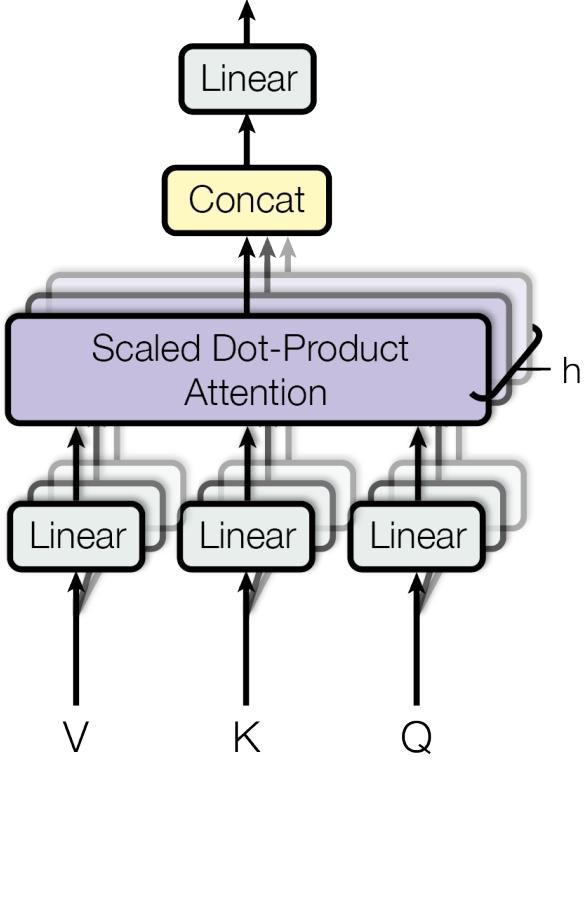

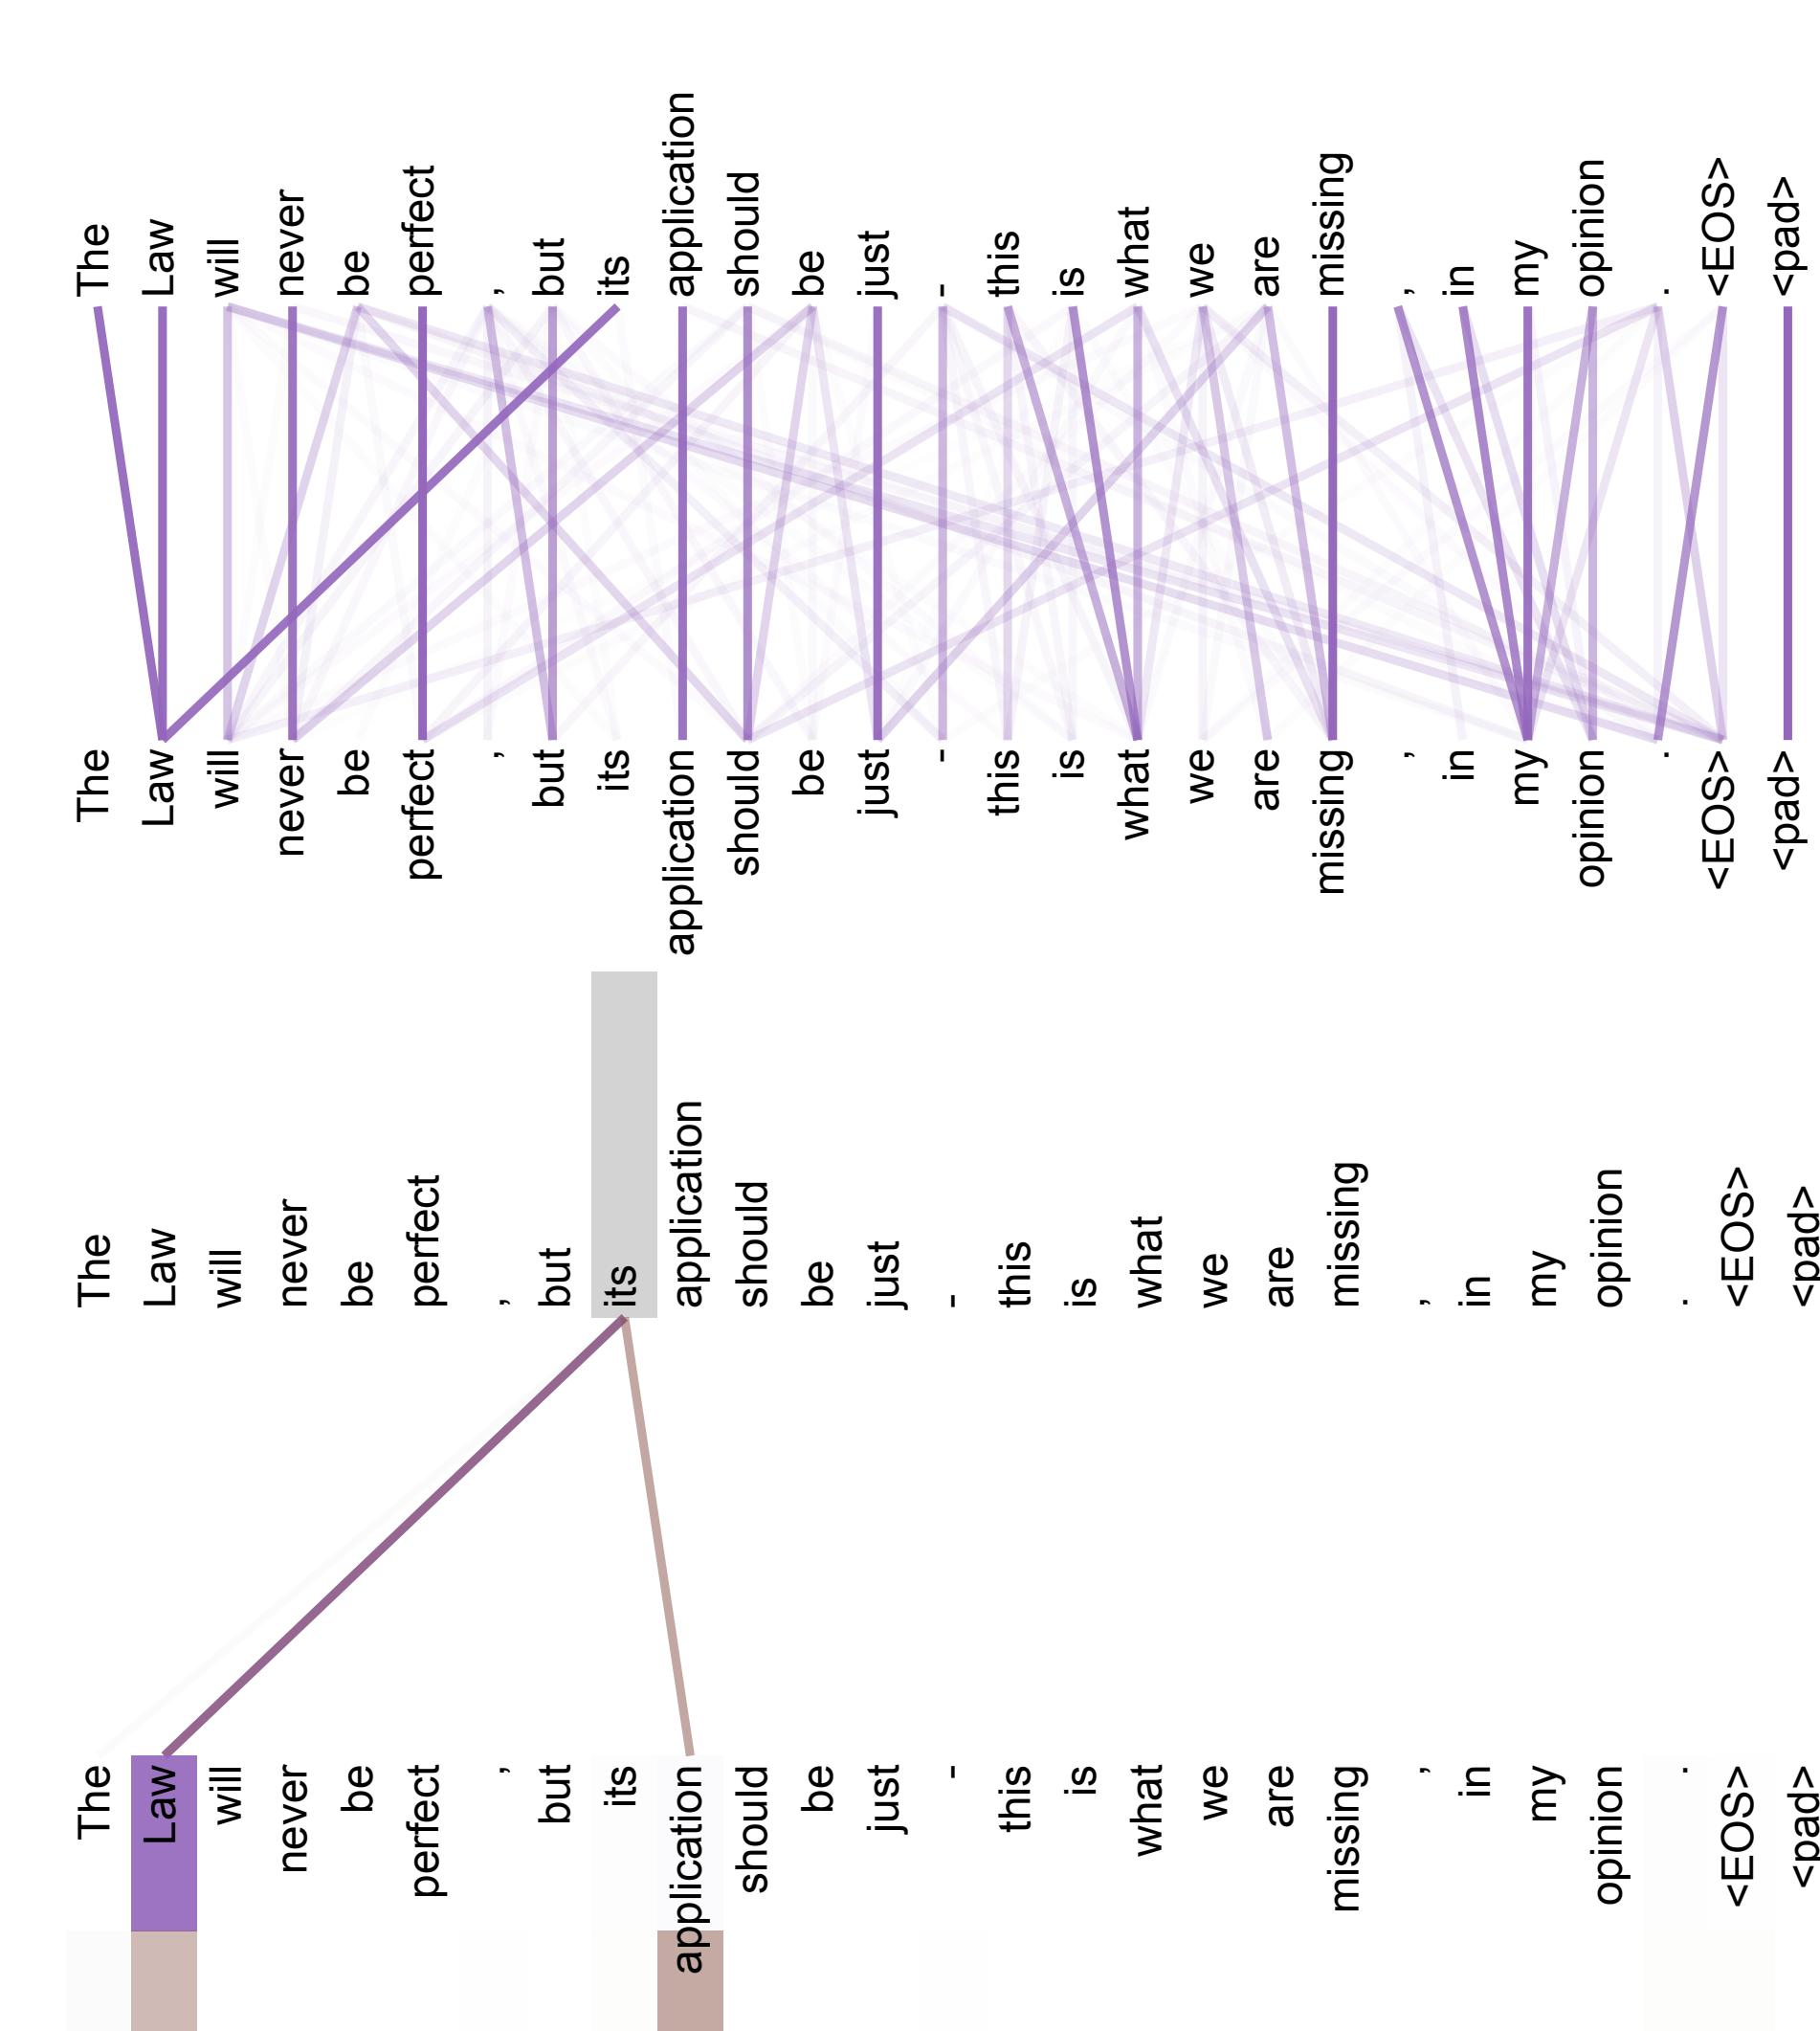

In [24]:
response = chain_with_sources.invoke(
    "What is multihead attention?"
)

print("Response:", response['response'])

print("\n\nContext:")
for text in response['context']['texts']:
    text_content = getattr(text, "text", str(text))
    print(text_content)
    page_number = getattr(text.metadata, "page_number", "n/a") if hasattr(text, "metadata") else "n/a"
    print("Page number: ", page_number)
    print("\n" + "-" * 50 + "\n")
for image in response['context']['images']:
    display_base64_image(image)


## References

- [LangChain Inspiration](https://github.com/langchain-ai/langchain/blob/master/cookbook/Semi_structured_and_multi_modal_RAG.ipynb?ref=blog.langchain.dev)
- [Multivector Storage](https://python.langchain.com/docs/how_to/multi_vector/)
- [LangChain Google Gemini integration](https://python.langchain.com/docs/integrations/chat/google_generative_ai/)